In [1]:
import pandas as pd
import numpy as np

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import precision_score
from sklearn.ensemble import RandomForestClassifier

# Misc tools
from tqdm.notebook import tqdm
import os
import re
import time
import warnings
warnings.filterwarnings("ignore")

In [2]:
ml_df = pd.read_pickle('2023-04-04_NB4_ml_df.pkl')

To determine the appropriate models and hyper-parameters to implement into our pipeline, we will examine each model using the following protocol:

Goal: Identify the ideal models and hyper-parameter optimization ranges to implement into gridsearchCV to not waste computing time on testing every model with every range of parameter optimization values.

1. Fit the model to our data once using default hyper-parameter settings to gauge a baseline training and testing accuracy.
2. 
3. Investigate possible sources of error 
3. Perform a raster-scan fitting of a large range of hyper-parameters to determine an 

`ml_df` is our data set for performing machine learning. Here the target column is `PubTier`, which is the tier that each citation is classified in, while the remaining statistics for the first, second and third authors are the features.

In [3]:
ml_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 16029 entries, 0 to 16028
Data columns (total 45 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   PubTier                           16029 non-null  int8   
 1   first_auth_Mean_AuthorRank        16029 non-null  float16
 2   first_auth_Mean_Cites             16029 non-null  float16
 3   first_auth_Mean_Year              16029 non-null  float16
 4   first_auth_Mean_CitesPerYear      16029 non-null  float16
 5   first_auth_Mean_CitesPerAuthor    16029 non-null  float16
 6   first_auth_Mean_AuthorCount       16029 non-null  float16
 7   first_auth_Mean_SJR               16029 non-null  float16
 8   first_auth_Mean_H index           16029 non-null  float16
 9   first_auth_Mean_PubTier           16029 non-null  float16
 10  first_auth_NumPapers_inDataset    16029 non-null  float16
 11  first_auth_Author_Hindex          16029 non-null  float16
 12  seco

In [4]:
def plt_hp_opt(x, train_scores, test_scores, xlabel, title):
    '''
    
    This function is designed to create a matplotlib plt isntance for plotting the results of hyperparameter optimizations.
    It is designed so any additional methods to edit the plot can be done after this function is called.
    
    Parameters:
    ----------
    x: The values for the x-axis
    train_scores: A list of values of the training scores
    test_scores: A list of values of the test scores
    xlabel: A str to be used as the xlabel
    title: A str to be added to the title
    
    '''
    plt.plot(x, train_scores, marker = '.', label = 'Train')
    plt.plot(x, test_scores, marker = '.', label = 'Test')
    plt.xlabel(xlabel)
    
    y_ticks = np.arange(0.6, 1.02, 0.02)
    y_labels = ['{:.0%}'.format(i) for i in y_ticks]
    plt.yticks(y_ticks, y_labels)
    
    plt.ylabel('Model Accuracy')
    plt.title(f'{title} Hyperparameter Optimization')
    plt.legend()
    plt.grid()

## Model 1: Logistic Regression

### Initial Model Fitting
Let's fit a logistic regression model to our data once using default hyper-parameter settings to gauge a baseline training and testing accuracy and precision metrics. We will use a train-test split of `test_size` = 25%, set `solver` to `lbfgs` to specify the algorithm to when fitting the logistic regression model, and set `random_state`= 1 to ensure that the model can be replicated with the same results every time it is trained. The training and testing accuracy scores will be outputted.

In [5]:
# Define features and target colums
X_train = ml_df.drop('PubTier', axis = 1)
y_train = ml_df['PubTier']

# Perform train-test split
X_train, X_test, y_train, y_test =  train_test_split(X_train, y_train, test_size=0.25, random_state = 1)

In [6]:
# Sclae the data using a standard scaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [7]:
# 1. Instantiate model
logit = LogisticRegression(solver='lbfgs', random_state=1, C = 1)

# 2. Fit model
logit.fit(X_train_scaled, y_train);

# 3. Score model
train_score = logit.score(X_train_scaled, y_train)
test_score = logit.score(X_test_scaled, y_test)
diff = train_score-test_score

# Get class predictions
y_pred = logit.predict(X_test_scaled)
pre_score =  precision_score(y_test, y_pred, average='weighted')

print('Model Used: Logistic Regression')
print('Parameter Used:   C =', 1)
print('\n')
print('--- Results ---')
print('Score on Train: {:0.2%}'.format(train_score))
print('Score on Test: {:0.2%}'.format(test_score))
print('Difference Between Training and Test Scores: {:0.2%}'.format(diff))
print('Weighted Precision Score: {:0.2%}'.format(pre_score))

Model Used: Logistic Regression
Parameter Used:   C = 1


--- Results ---
Score on Train: 76.12%
Score on Test: 75.60%
Difference Between Training and Test Scores: 0.52%
Weighted Precision Score: 75.83%


With the default hyper-parameter settings (`C`= 1) the logistic regression model was able to fit the training data with 76.12% accuracy and the testing data with 75.60% accuracy, additionally, the difference between training and testing scores being < 1% suggests that there is minimal over-fitting which could hopefully be solved optimizing the weight of the cost function in for the assigned penalty (L2, in our case). The weighted precision score of 75.83% suggests that observations were classified into their correct class nearly 76% of the time, though there is much room for improvement.

### Optimizing Model Accuracy

#### Part 1: Addressing Multicollinearity
Since logistic regression is a linear classification model, before perform considering the landscape of hyper-parameters to increase model accuracy, we should first access the other potential issues that could hinder the accuracy of the model, such as multicollinearity.

We can investigate multicollinearities between features using a heat map.

In [8]:
ml_corr = ml_df.drop('PubTier', axis = 1).corr()

Text(0.5, 1.0, 'Absolute Value of Correlations Between Features')

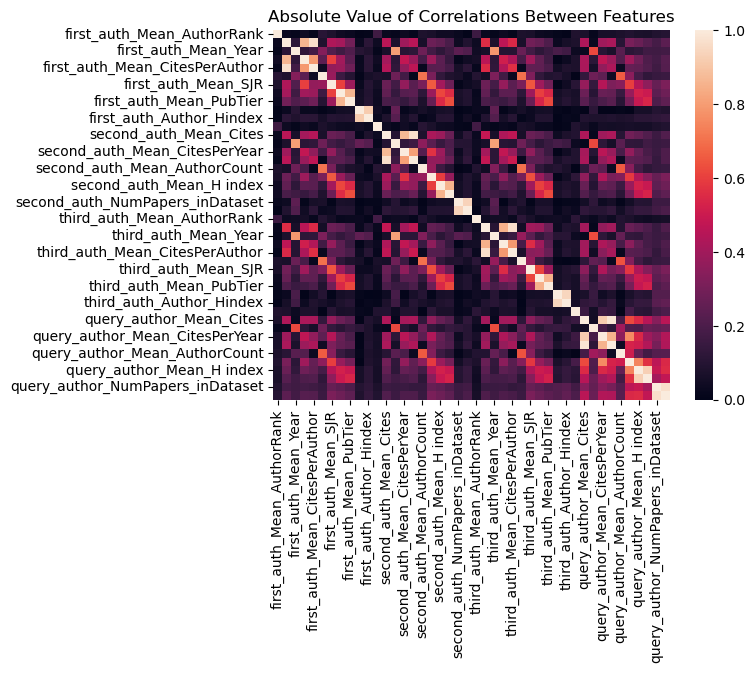

In [9]:
sns.heatmap(np.abs(ml_corr), vmin = 0, vmax = 1)
plt.title('Absolute Value of Correlations Between Features')

From the heatmap, we see that there are areas where collinearity between features is strong, i.e., > 0.5. Let's rescale the heatmap to highlight those collinearities.

Text(0.5, 1.0, 'Absolute Value of Correlations Between Features\nRescaled to Feature Correlations >= 0.5')

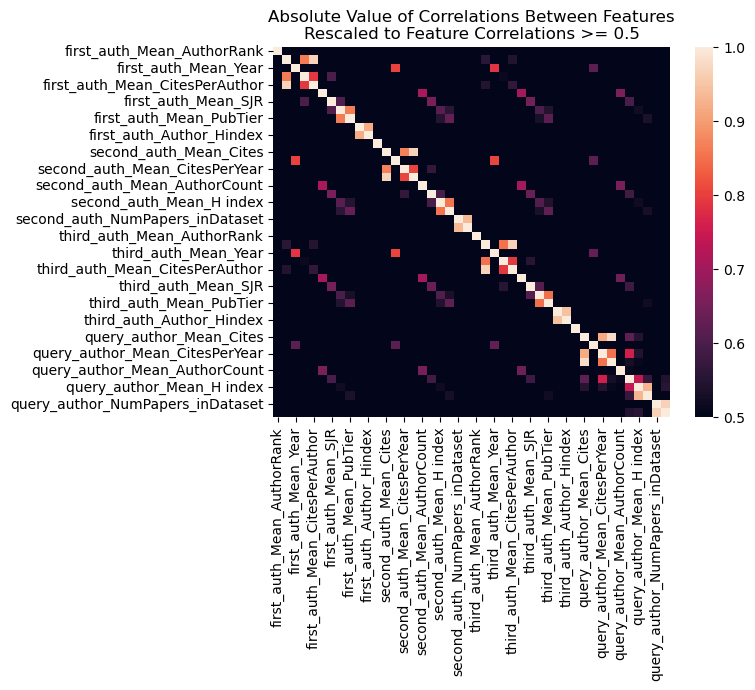

In [10]:
sns.heatmap(np.abs(ml_corr), vmin = 0.5, vmax = 1)
plt.title('Absolute Value of Correlations Between Features\nRescaled to Feature Correlations >= 0.5')

From this rescaled heat map, we see that most of the features have a correlation to another feature that has an absolute value over 0.5, with some features have correlations to another feature with a value over 0.8. Since our data set has < 50 features and most of the features attributes to the multicollinearity, removing select features through feature selection is unlikely going to solve multicollinearity issue. Instead, removing what limited features the model does have could result in the model being less generalizable if the limited columns selected do not adequately capture the variance in the data set. Overall, given the wide-spread multicollinearity and limited number of features, pursuing logistic regression as our classification model may not be ideal. 

However, we could employ a method of dimensionality reduction, such as principal vector component analysis (PCA) to reduce the number of columns, which could reduce multicollinearity, while preserving the variance in the data set. The effectiveness of PCA at capturing the variance of the data set can be quantified using the *explained variance ratio* for each of principle component (PC) describe the variation in the data set. Specifically, the explained variance ratio describes the *percentage* of the variance that each PC is able to account for, with the goal of increasing the number of PCs until all the variance in the data set can be adequately captured.

We can identify the number of PCs that adequately capture the variance in our data set by making a line plot of the explained variance ratios and identifying the elbow in the plot to decide how many PCs are  adequate. The number of PCs at the elbow in the plot will identify the threshold for where any additional PCs will not substantially raise the explained variance, and are therefore redundant at explaining the variance in the data set.

The number of PCs can be controlled using the `n_components` hyper-parameter. Let's examine how the number of principal components by examining the *explained variance ratios* for each.

In [11]:
n_list = np.arange(2, 40, 2)
EVR_list = []

for n in n_list:
    # Initiate PCA Model
    my_PCA = PCA(n_components = n)

    # Fit to training data
    my_PCA.fit(X_train_scaled)

    # Transform Training and Testing data
    X_train_PCA = my_PCA.transform(X_train_scaled)
    X_test_PCA = my_PCA.transform(X_test_scaled)
    EVR = my_PCA.explained_variance_ratio_
    EVR_list.append(EVR)

In [12]:
# Turing the list into an array with the explained variance of each PCA component
EVR_arr = np.zeros(n_list.shape[0])
for i in range(n_list.shape[0]):
    EVR_arr[i] = EVR_list[i][i]

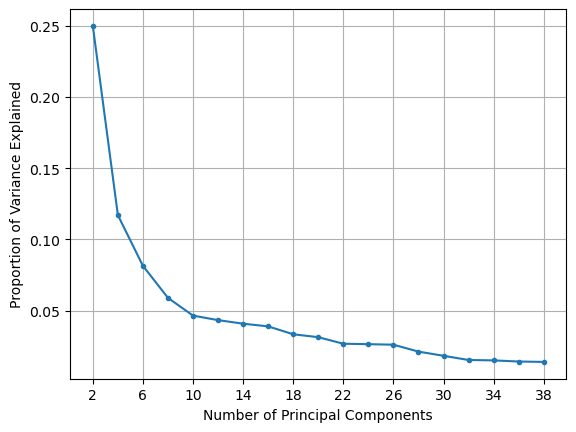

In [13]:
plt.plot(n_list, EVR_arr, marker = '.')
plt.xlabel('Number of Principal Components')
plt.ylabel('Proportion of Variance Explained')
plt.grid()
x_ticks = np.arange(2, 40, 4)
plt.xticks(x_ticks, x_ticks);

Here we see that the elbow in the plot is between 6-10 PCs suggesting that any additional PCs added beyond that will not substantially raise the explained variance. However, it appears that the explained variance ratio does not truly become constant until beyond 30 PCs so that the ideal number of PCs is anywhere between 6-30. This may be worth exploring during a grid search, but first we need to address if reducing the number of features using PCA will address the issue with multicollinearity. Let's look at a heat map of the PCA components for `n_components` = 6 and `n_components` = 30 to investigate.

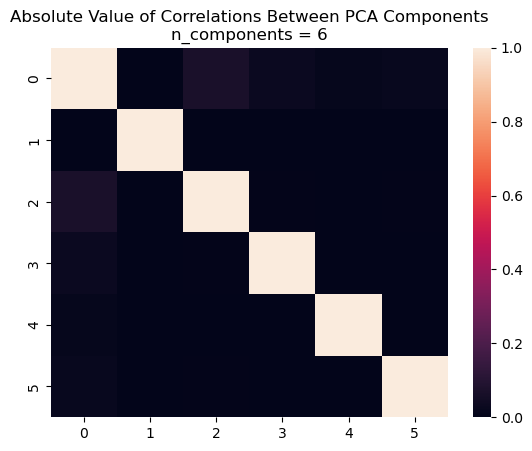

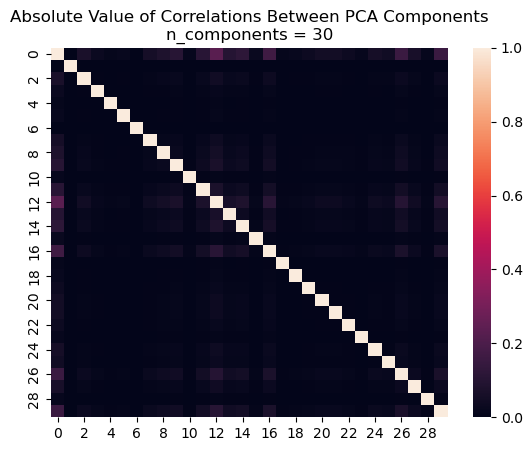

In [14]:
for i in [6, 30]:
    # Initiate PCA Model
    my_PCA = PCA(n_components = i)

    # Fit to training data
    my_PCA.fit(X_train);

    # Converting to DF to get correlation matrix. Transposing the array so that components are the columns.
    pca_corr = pd.DataFrame(my_PCA.components_.T).corr()

    sns.heatmap(np.abs(pca_corr), vmin = 0, vmax = 1)
    plt.title(f'Absolute Value of Correlations Between PCA Components\nn_components = {i}')
    plt.show()

From these results we observe that there are no longer any columns that have a correlation of > 0.5 for both the lower bound of `n_components` = 6 and upper bound of `n_components` = 30. These results suggests that any number of components between 6 and 30 selected by the grid search would not result in features that have strong correlations in between them, therefore suggesting the logistic regression could still be a feasible model for the data set when PCA in employed.

#### Part 2: Addressing Overfitting

We can optimize the hyper-parameter `C` in the logistic regression model in order to optimize the weight of the cost function. Let's examine how the training and testing accuracy changes for values of `C` over a large range ($10^{-5},10^{5}$).

In [15]:
c_vals = np.asarray([10**i for i in range(-5, 5)])
test_scores = []
train_scores = []

for c in c_vals:
    # 1. Instantiate model
    logit = LogisticRegression(solver='lbfgs', random_state=1, C = c)

    # 2. Fit model
    logit.fit(X_train_scaled, y_train);

    # 3. Score model
    train_score = logit.score(X_train_scaled, y_train)
    test_score = logit.score(X_test_scaled, y_test)
    train_scores.append(train_score)
    test_scores.append(test_score)

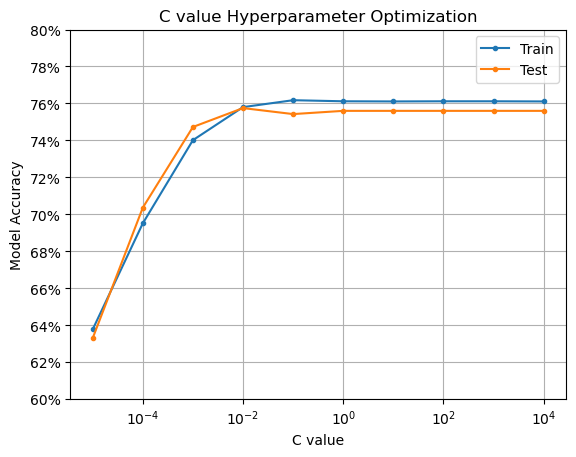

In [16]:
plt_hp_opt(c_vals, train_scores, test_scores,'C value', 'C value')
plt.xscale('log')
plt.ylim([0.6, 0.8]);

From these results, we see that logistic regression model suffers from *under fitting* for `C` $< 10^{-2}$ and switches to suffering from over fitting from `C` $> 10^{-2}$. It appears that the least amount of over and under fitting occurs at `C` $= 10^{-2}$, so a grid search for the optimal C values could be around `C` $= 10^{-2}$ (range of 0.005 to 0.0105, for example).

To further isolate the optimal range of `C` values for grid searching, let's apply the same analysis for the `C` values for the data set reduced using PCA with the lower bound `n_components` = 6 and upper bound `n_components` = 30.

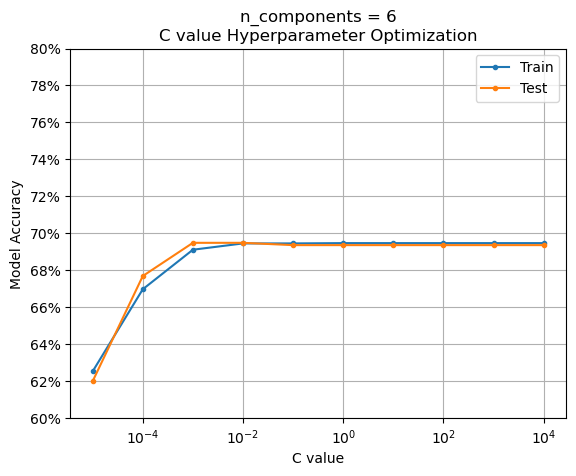

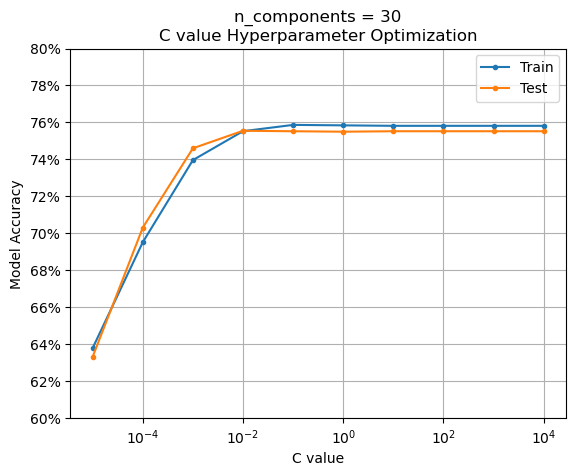

In [17]:
c_vals = np.asarray([10**i for i in range(-5, 5)])

for i in [6, 30]:
    # Initiate PCA Model
    my_PCA = PCA(n_components = i)

    # Fit to training data
    my_PCA.fit(X_train_scaled);
    
    X_train_PCA = my_PCA.transform(X_train_scaled)
    X_test_PCA = my_PCA.transform(X_test_scaled)
    
    test_scores = []
    train_scores = []

    for c in c_vals:
        # 1. Instantiate model
        logit = LogisticRegression(solver='lbfgs', random_state=1, C = c)

        # 2. Fit model
        logit.fit(X_train_PCA, y_train);

        # 3. Score model
        train_score = logit.score(X_train_PCA, y_train)
        test_score = logit.score(X_test_PCA, y_test)
        train_scores.append(train_score)
        test_scores.append(test_score)
    
    
    plt_hp_opt(c_vals, train_scores, test_scores,'C value', f'n_components = {i}\nC value')
    plt.xscale('log')
    plt.ylim([0.6, 0.8]);
    plt.show()

We get similar results the data set reduced using PCA with the lower bound `n_components` = 6 and upper bound `n_components` = 30 as we did the original data set, such as the logistic regression model suffers from *under fitting* for `C` $< 10^{-2}$ and switches to suffering from over fitting from `C` $> 10^{-2}$. However, for the data set reduced using `n_components` = 6, the under fitting for `C` $< 10^{-2}$  is much more exaggerated at `C` $<= 10^{-1}$ than the other two examples. Overall, this finding further supports the range of values for `C` for grid search to consider to be closer to $10^{-2}$ than $10^{-3}$ and $10^{-1}$ to optimize model fitting.

---

## Model 2: KNN Classifers

### Initial Fitting
Let's fit a K nearest-neighbor (KNN) model to our data once using default hyper-parameter settings to gauge a baseline training and testing accuracy and precision metrics. We will use the same train-test split with `test_size` = 25% as was used for the logistic regression model, as well as the feature columns scaled using `StandardScalar`. 

In [18]:
# 1. Instantiate model
knn = KNeighborsClassifier()

# 2. Fit model
knn.fit(X_train_scaled, y_train);

# 3. Score model
train_score = knn.score(X_train_scaled, y_train)
test_score = knn.score(X_test_scaled, y_test)
diff = train_score-test_score

# Get class predictions
y_pred = knn.predict(X_test_scaled)
pre_score =  precision_score(y_test, y_pred, average='weighted')

print('Model Used: KNN')
print('Parameter Used:  n_neighbors =', 5)
print('\n')
print('--- Results ---')
print('Score on Train: {:0.2%}'.format(train_score))
print('Score on Test: {:0.2%}'.format(test_score))
print('Difference Between Training and Test Scores: {:0.2%}'.format(diff))
print('Weighted Precision Score: {:0.2%}'.format(pre_score))

Model Used: KNN
Parameter Used:  n_neighbors = 5


--- Results ---
Score on Train: 78.06%
Score on Test: 66.92%
Difference Between Training and Test Scores: 11.14%
Weighted Precision Score: 68.00%


With the default hyper-parameter settings (`n_neighbors`= 5) the KNN model was able to fit the training data with 78.06% accuracy and the testing data with 66.92% accuracy. Unlike the logistic regression model, the difference between training and testing scores was over > 1%. In fact, the difference was > 10% (11.14%) suggesting there is most over fitting in the KNN model with the default parameters than the logistic regression model. The weighted precision score of 68.00% suggests that observations were classified into their correct class nearly 68% of the time, which is also a lower percentage of precision compared to that of the logistic regression model (78%). These results conclude that logistic regression may be the ideal model for classifying the citations into publication tiers, however let's test to see if changing the value of `n_neighbors` could increase the KNN model accuracy.

### Optimizing Model Accuracy

Let's see the model accuracy for KNN changes with integer step-size values of `n_neighbors` over a range of 5 to 20.

In [19]:
n_list = np.arange(5, 43, 2)
test_scores = []
train_scores = []

for n in tqdm(n_list):
    # 1. Instantiate model
    knn = KNeighborsClassifier(n_neighbors = n)

    # 2. Fit model
    knn.fit(X_train_scaled, y_train);
    
    # 3. Score model
    train_score = knn.score(X_train_scaled, y_train)
    test_score = knn.score(X_test_scaled, y_test)
    train_scores.append(train_score)
    test_scores.append(test_score)

  0%|          | 0/19 [00:00<?, ?it/s]

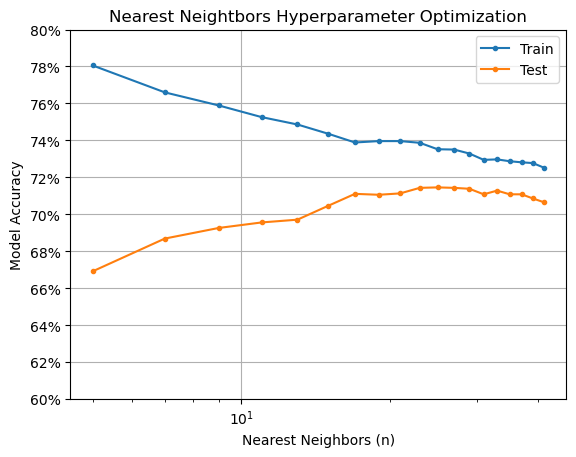

In [20]:
plt_hp_opt(n_list, train_scores, test_scores,'Nearest Neighbors (n)', 'Nearest Neightbors')
plt.xscale('log')
plt.ylim([0.6, 0.8]);

From the results, we observe the training and testing accuracy converging towards 0.72 as `n_neighbors` increases. Although past `n_neighbors` = 35, the testing accuracy starts to diverge from 0.72, which would be consistent with the model having a greater tendency to over fit when the `n_neighbors` reaching the number of features in the data set (44). Overall, from this analysis, it appears that changing the values of `n_neighbors` would not decrease the gap between the training and testing accuracy doesn't decrease below 1% as it did for logistic regression. Therefore, including KNN in the grid search pipeline to fine the best model would not be a efficient use of computational time.

---

## Model 3: Decision Tree

### Initial Fitting

Let's fit a Decision Tree model to our data once using default hyper-parameter settings to gauge a baseline training and testing accuracy and precision metrics. We will use the same train-test split with `test_size` = 25% as was used for the logistic regression model, as well as the feature columns scaled using `StandardScalar`.

In [21]:
# 1. Instantiate model
dt = DecisionTreeClassifier()

# 2. Fit model
dt.fit(X_train_scaled, y_train);

# 3. Score model
train_score = dt.score(X_train_scaled, y_train)
test_score = dt.score(X_test_scaled, y_test)
diff = train_score-test_score

# Get class predictions
y_pred = dt.predict(X_test_scaled)
pre_score =  precision_score(y_test, y_pred, average='weighted')

print('Model Used: Decision Tree')
print('Parameter Used:\nmax_depth = None\nmin_samples_split = 2')
print('\n')
print('--- Results ---')
print('Score on Train: {:0.2%}'.format(train_score))
print('Score on Test: {:0.2%}'.format(test_score))
print('Difference Between Training and Test Scores: {:0.2%}'.format(diff))
print('Weighted Precision Score: {:0.2%}'.format(pre_score))

Model Used: Decision Tree
Parameter Used:
max_depth = None
min_samples_split = 2


--- Results ---
Score on Train: 97.35%
Score on Test: 74.23%
Difference Between Training and Test Scores: 23.12%
Weighted Precision Score: 74.33%


With the default hyper-parameter settings (`max_depth`= None, `min_samples_split` = 2) the decision tree model was able to fit the training data with 97.35% accuracy and the testing data with 74.48% accuracy. While the decision tree model has the highest training accuracy of all the inital model fittings and second highest testing accuracy compared to the initial model fitting for logsitic regression (75.60%), the decision tree model also had the largest difference bewteen the training and testing accuracy (22.87%) between the three models. This difference suggests the decision tree model resulted in the most over fitting of the three models in their inital runs. However, like we suggested for the KNN modeling, the model accuracy and fitting can be improved by optimizing on the hyper-parameters. Regaurding the precision score, the 74.16% from the inital decision tree model suggest that the model is about classify the the observation correctly 74% of the time, which is improved from the inital precision of the KNN mdodel (68%) but slightly below the precision of the inital logistic regression model (76%).

### Optimizing Model Accuracy

To access how the model accuracy for decision trees changes with hyper-parameter optimization, let's observe how the model accuracy changes with integer step-sizes of `max_depth`. Here, the `max_depth` parameter will control for the number of nodes the decision tree can produce, which could result in the model over fitting to the trianing set if left too high. In its default state, the `max_depth` was set to `None` which left the termination to the node production to the defualt `min_samples_split` parameter, which defined how many observations were required to be categorized in a node for it to split.

In [22]:
d_list = np.arange(5, 43, 2)
test_scores = []
train_scores = []

for d in tqdm(d_list):
    # 1. Instantiate model
    dt = DecisionTreeClassifier(max_depth = d)

    # 2. Fit model
    dt.fit(X_train_scaled, y_train);
    
    # 3. Score model
    train_score = dt.score(X_train_scaled, y_train)
    test_score = dt.score(X_test_scaled, y_test)
    train_scores.append(train_score)
    test_scores.append(test_score)

  0%|          | 0/19 [00:00<?, ?it/s]

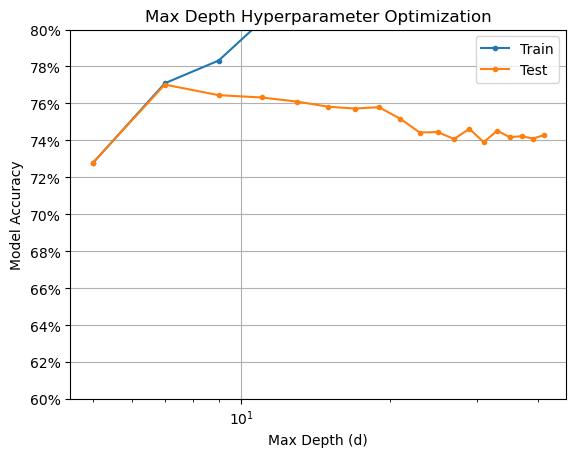

In [23]:
plt_hp_opt(d_list, train_scores, test_scores,'Max Depth (d)', 'Max Depth')
plt.ylim([0.7, 1]);

From these results, we found that decision tree model achieved the least amount of over/under fitting (i.e., the most generalizability) for values of `max_depth` $< 9$, and over fitting starting to dominate the trend for values `max_depth` $\geq 9$. Interestingly, for the `max_depth` values between 5 and 9, both the training and testing acuracy rose from 73-77% while remaining the same. These findings suggests that the within those ranges of `max_depth`, the accuracy of the model can increase while maintaining generalizability. Alternatively, let's investigate if optimizing the `min_sample_split` instead of the `max_depth` parameter could lead to improved model accuracy.

In [24]:
ss_list = np.arange(2, 42, 2)
test_scores = []
train_scores = []

for s in tqdm(ss_list):
    # 1. Instantiate model
    dt = DecisionTreeClassifier(min_samples_split = s)

    # 2. Fit model
    dt.fit(X_train_scaled, y_train);
    
    # 3. Score model
    train_score = dt.score(X_train_scaled, y_train)
    test_score = dt.score(X_test_scaled, y_test)
    train_scores.append(train_score)
    test_scores.append(test_score)

  0%|          | 0/20 [00:00<?, ?it/s]

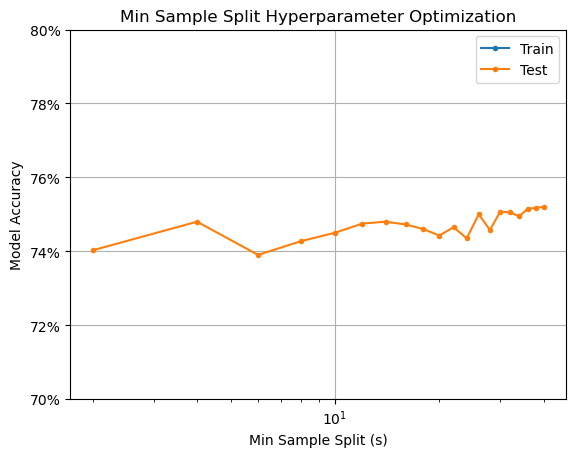

In [25]:
plt_hp_opt(ss_list, train_scores, test_scores,'Min Sample Split (s)', 'Min Sample Split')
plt.ylim([0.70, 1]);

From these results, we see that optimizing the `min_sample_split` parameter leads to more over-fitting of the model compared to the `max_depth` parameter. Therefore, the training and testing accuracy from the range of `max_depth` values between 5 and 9 demonstrate the `max_depth` parameter provides the best model generalizability. Regarding the classification accuracy, optimizing both the `min_sample_split` parameter and `max_depth` produce training accuracy > 85%, and testing accuracies near 75%. Therefore, since the parameter provides the results with the most generalizability, when optimizing the decision tree model using grid search, the `max_depth` parameter should be optimized between values of 5 and 9.

##  Model 4: Random Forest Model

### Initial Fitting

From the success of the decision tree model, let try to fit a random forest model to see if bootstrapping and aggregating will improve the accuracy of the decision tree model. 

Like the other models, the initial fit will be done using the default hyper-parameter settings to gauge a baseline training and testing accuracy and precision metrics. In this case, `n_estimators`  = 100. However, given the success of the decision tree model with a defined `max_depth` parameter between 5 and 9, will also define `max_depth` = 7 so that we can focus our study on optimizing the `n_estimators` parameter to achieve the best model accuracy. We will use the same train-test split with `test_size` = 25% as was used for the logistic regression model, as well as the scaled feature columns scaled using `StandardScalar`.

In [51]:
# 1. Initiate the Model
random_forest_model = RandomForestClassifier(max_depth = 7)
# 2. Score the Model
random_forest_model.fit(X_train_scaled, y_train)

# 3. Score model
train_score = random_forest_model.score(X_train_scaled, y_train)
test_score = random_forest_model.score(X_test_scaled, y_test)
diff = train_score-test_score

# Get class predictions
y_pred = random_forest_model.predict(X_test_scaled)
pre_score =  precision_score(y_test, y_pred, average='weighted')

print('Model Used: Random Forest')
print('Parameter Used:\nmax_depth = 7\nn_estimators = 100')
print('\n')
print('--- Results ---')
print('Score on Train: {:0.2%}'.format(train_score))
print('Score on Test: {:0.2%}'.format(test_score))
print('Difference Between Training and Test Scores: {:0.2%}'.format(diff))
print('Weighted Precision Score: {:0.2%}'.format(pre_score))

Model Used: Random Forest
Parameter Used:
max_depth = 7
n_estimators = 100


--- Results ---
Score on Train: 78.88%
Score on Test: 77.37%
Difference Between Training and Test Scores: 1.51%
Weighted Precision Score: 79.64%


With the default hyper-parameter settings (`n_estimators` = 100) and `max_depth` = 7,  the decision tree model could fit the training data with 78.78% accuracy and the testing data with 77.57% accuracy. With the difference between the training and testing scores being near 1% (1.21%), the generalizability of the initial fitting of the random forest model proves to be the most competitive with the initial fitting of the logistic regression model that had a training and testing score difference of 0.52%. In addition to their similar values for the difference between the training and testing sets, the training and testing accuracy and precision score for the initial random forest model (78.78%, 77.57%, 79.64%) is shown to be within 3% of the training and testing accuracy and precision score for the initial logistic regression model (76.12%, 74.60%, 74.31%), respectively. These results suggest that the random forest model could be the strongest competitor against logistic regression for classifying the citations into publication tiers compared to the initial modeling results alone. However, let's first investigate if optimizing the parameter `n_estimators` could potentially provide higher accuracies and improved generalizability compared to previously tested models.

### Optimizing Model Accuracy

Let's access how the model accuracy for the random forest model changes with optimization using large integer step-sizes of `n_estimators`. Here `n_estimators` determines the number of *trees* each 

In [27]:
es_list = np.arange(10, 1000, 100)
test_scores = []
train_scores = []

for e in tqdm(es_list):
    
    # 1. Instantiate model
    random_forest_model = RandomForestClassifier(n_estimators = e, max_depth = 7)
    
    # 2. Fit model
    random_forest_model.fit(X_train_scaled, y_train);
    
    # 3. Score model
    train_score = random_forest_model.score(X_train_scaled, y_train)
    test_score = random_forest_model.score(X_test_scaled, y_test)
    train_scores.append(train_score)
    test_scores.append(test_score)

  0%|          | 0/10 [00:00<?, ?it/s]

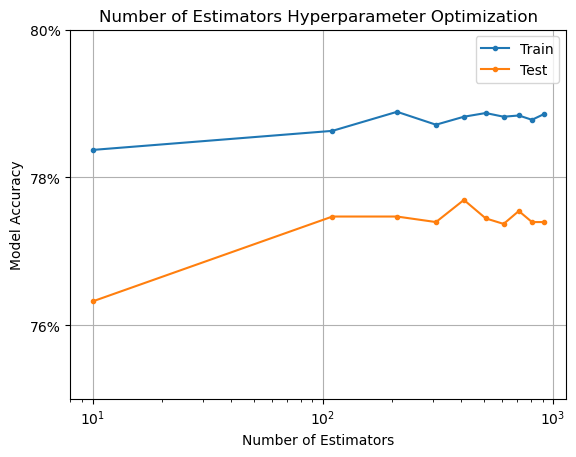

In [38]:
plt_hp_opt(es_list, train_scores, test_scores,'Number of Estimators', 'Number of Estimators')
plt.xscale('log')
plt.ylim([0.75, 0.80]);

In [29]:
idx = np.where(np.min(np.subtract(train_scores, test_scores)) == np.subtract(train_scores, test_scores))
print('The number of estimators with the smallest train/test accuracy difference is', es_list[idx][0])

The number of estimators with the smallest train/test accuracy difference is 410


From these results, we found that the training accuracy stays within 0.25% of 78.75%, and the testing accuracy stays within 0.7% of 77.50% for the range of estimators. These results suggest that the training and testing accuracy is not sensitive to the `n_estimator` parameter. Additionally, the difference between the training and testing accuracy stays within 1.3-1.5%, suggesting that the model's generalizability is not sensitive to the `n_estimator` parameter. Therefore, when considering building a computationally efficient pipeline to find the best model, it would be most computationally efficient to optimize the random forest model without performing a grid search on `n_estimators` and instead using a value from this study that gives the smallest difference between the training and testing data, which in this case is `n_estimators` = 410. Here, computational time for the pipe line could be focused on fitting the the random forest model to an optimal value of `max_depth`, which suggested to be a critical parameter to optimize to ensure generalizability of individual decision trees.

## Choosing the Best Models for Grid Search

To determine the best models and parameters for the grid search, let's compare the accuracy and precision results of the initial fitting predictions for each model with their pseudo-optimal hyper-parameters to determine which models have the most potential to classify the citations into tiers. Here, the pseudo-optimal hyper-parameters will be chosen within the proposed range of values suggested by the hyper-parameter optimization. Though the fit fitted to the pseudo-optimal hyper-parameters won't represent the final model fit, it will be used to judge the potential of each individual model against each other.

In [30]:
#Model order
model_list = ['LogReg', 'KNN', 'DecisionTrees', 'RandomForest']

# Define inital model (default settings)
in_logit = LogisticRegression(solver='lbfgs', random_state=1)
in_knn = KNeighborsClassifier()
in_dt = DecisionTreeClassifier()
in_rf = RandomForestClassifier(max_depth = 7)

in_models = [in_logit, in_knn, in_dt, in_rf]

# Define pseudo-optimal models 
po_logit = LogisticRegression(solver='lbfgs', random_state=1, C = 10E-2)
po_knn = KNeighborsClassifier(n_neighbors = 33)
po_dt = DecisionTreeClassifier(max_depth = 7)
po_rf = RandomForestClassifier(n_estimators = 410, max_depth = 7)

po_models = [po_logit, po_knn, po_dt, po_rf]

In [172]:
# Creating a dictionary to store the results in
dic = {'model': [], 'Training Score':[], 'Testing Score': [], 'Test/Training Score Difference': [], 'Weighted\nPrecision Score':[]}

In [173]:
# for psuedo-optimized models

for i in range(len(po_models)):
    
    # 1. Grab Model
    model = po_models[i]
    
    if i == 0 and model_list[i] == 'LogReg': # if LogRegression, perform PCA transformation
        
        # Initiate PCA Model
        my_PCA = PCA(n_components = 30)

        # Fit to training data
        my_PCA.fit(X_train_scaled);
    
        X_train_PCA = my_PCA.transform(X_train_scaled)
        X_test_PCA = my_PCA.transform(X_test_scaled)
        
        # 2. Fit the Model
        model.fit(X_train_PCA, y_train)
        
        # 3. Score model
        train_score = model.score(X_train_PCA, y_train)
        test_score = model.score(X_test_PCA, y_test)
        diff = train_score-test_score

        # Get class predictions
        y_pred = model.predict(X_test_PCA)
        pre_score =  precision_score(y_test, y_pred, average='weighted')
    
    else:
        # 2. Fit the Model
        model.fit(X_train_scaled, y_train)

        # 3. Score model
        train_score = model.score(X_train_scaled, y_train)
        test_score = model.score(X_test_scaled, y_test)
        diff = train_score-test_score

        # Get class predictions
        y_pred = model.predict(X_test_scaled)
        pre_score =  precision_score(y_test, y_pred, average='weighted')

    dic['model'].append(model_list[i])
    dic['Training Score'].append(train_score)
    dic['Testing Score'].append(test_score)
    dic['Test/Training Score Difference'].append(diff)
    dic['Weighted\nPrecision Score'].append(pre_score)

In [174]:
# Initiate results dictionary
results_df = pd.DataFrame(dic)

In [261]:
gs[0]

GridSpec(1, 3, width_ratios=[0.45, 0.45, 0.1])[0:1, 0:1]

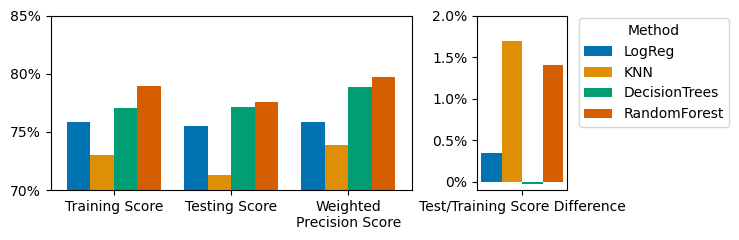

In [286]:
import matplotlib.gridspec as gridspec
color_pal = sns.color_palette("colorblind")
fig = plt.figure(figsize = (7.5, 2.5))

gs = fig.add_gridspec(nrows=1, ncols=2, width_ratios=[0.80, 0.20])
axes = [fig.add_subplot(gs[i]) for i in range(0,2)]

cols = ['Training Score', 'Testing Score', 'Weighted\nPrecision Score', 'Test/Training Score Difference']

j = 0
k = 0
for col in cols:
    i = 0
    for model in model_list:
        bar_val = results_df[results_df['model'] == model][col]
        if col != 'Test/Training Score Difference':
            axes[0].bar(j, bar_val, width = 0.25, color = color_pal[i], label = model)
            j += 0.25
            i += 1
        elif col == 'Test/Training Score Difference':
            axes[1].bar(k, bar_val, width = 1, color = color_pal[k], label = model)
            k += 1
    j += 0.25

# for axes [0,0]
axes[1].legend(title = 'Method', bbox_to_anchor=(1.05, 1.025))

# for axes[0]
x_ticks = np.arange(0.375, 3.375, 1.25)
axes[0].set_xticks(x_ticks, cols[:3]);
y_ticks = np.arange(0, 1, 0.05)
y_labels = ['{:.0%}'.format(i) for i in y_ticks]
axes[0].set_yticks(y_ticks, y_labels)
axes[0].set_ylim([0.70, 0.85])

# for axes[1]
x_ticks = [1.5]
y_ticks = np.arange(0, 1, 0.005)
y_labels = ['0%'] + ['{:.1%}'.format(i) for i in y_ticks[1:]]
axes[1].set_yticks(y_ticks, y_labels)
axes[1].set_xticks(ticks = x_ticks, labels = [cols[-1]]);
axes[1].set_ylim([-0.001, 0.02])
  
fig.tight_layout()

Random Forest out performs all other models, let's do gridsearch just on random forest.

In [308]:
from tempfile import mkdtemp
# Define features and target colums
X_train = ml_df.drop('PubTier', axis = 1)
y_train = ml_df['PubTier']

# Perform train-test split
X_train, X_test, y_train, y_test =  train_test_split(X_train, y_train, test_size=0.25, random_state = 1)

#Define estimators
estimators = [
    ('scalar', StandardScaler()),
    ('model', DecisionTreeClassifier())]

depth_vals = np.arange(5, 10, 0.025)
n_est_vals = np.arange(405, 421, 1)

# Initiate Pipeline object
cachedir = mkdtemp()
pipe = Pipeline(estimators, memory = cachedir)

# Define parameter grid for grid search
param_grid = [
    {'model': [RandomForestClassifier()],
     'scalar':[StandardScaler()],
     'model__n_estimators': n_est_vals,
    'model__max_depth': depth_vals},
    {'model': [DecisionTreeClassifier()],
     'scalar':[StandardScaler()],
    'model__max_depth': depth_vals}
]

# Initiate the GridSearchCV object with a 5-fold cross validation
grid = GridSearchCV(pipe, param_grid=param_grid, cv = 5)

# Perform the grid search, fitting the grid search to the training data only
grid.fit(X_train, y_train)

KeyboardInterrupt: 

In [ ]:
import joblib

#save your model or results
joblib.dump(grid, 'NB5_gsModel.pkl')